# ARTI-309 - Mathematical Foundations for AI
# Student Emotion Detection Optimization

## Introduction

In this case study, we explore how Gradient Descent can be applied to optimize an emotion classification model using facial expression data.

The objective of this experiment is to analyze how the model minimizes the loss function by iteratively updating the weights and bias parameters during training.

The dataset used in this study contains facial images representing different emotions such as anger, sadness, happiness, fear, disgust, surprise, and contempt.

This case study focuses on:
- Gradient Descent optimization  
- Loss and cost reduction  
- Weight and bias updates  
- Learning rate effects  
- Convergence behavior  

Rather than building a highly complex deep learning system, the main goal is to understand the mathematical foundations behind optimization in machine learning models.

---

## Dataset

The dataset used in this experiment is the CK+ (Cohn-Kanade) facial expression dataset.

The dataset contains:
- Facial expression images  
- Multiple emotion categories  
- Images resized to 128×128 pixels  
- Seven emotion classes:
  - anger
  - contempt
  - disgust
  - fear
  - happy
  - sadness
  - surprise

### 1. Importing Libraries

In [57]:
import os                                # handle file and folder paths
import kagglehub                         # download datasets from Kaggle
import numpy as np                       # numerical computations and arrays
import matplotlib.pyplot as plt          # plotting graphs and visualizations

import torch                             # main PyTorch library
import torch.nn as nn                    # neural network modules
import torch.optim as optim              # optimization algorithms (Gradient Descent)

from torchvision import datasets, transforms           # image datasets and preprocessing tools
from torch.utils.data import DataLoader, random_split  # load and split dataset
from tqdm import tqdm                                  # display training progress bars

from sklearn.metrics import classification_report, confusion_matrix  # evaluation metrics
import seaborn as sns                                                # advanced data visualization

### 2. Loading the Dataset

In [58]:
path = kagglehub.dataset_download("shawon10/ckplus")   # download the CK+ dataset from Kaggle
data_path = os.path.join(path, "CK+48")                # create the path to the image folder

print(data_path)                                       # display dataset location
print(os.listdir(data_path))                           # display emotion class folders

C:\Users\hayaa\.cache\kagglehub\datasets\shawon10\ckplus\versions\1\CK+48
['anger', 'contempt', 'disgust', 'fear', 'happy', 'sadness', 'surprise']


### 3. Transform the Dataset

In [ ]:
transform = transforms.Compose([                 # define image preprocessing steps
    transforms.Resize((128, 128)),               # resize all images to 128x128 pixels
    transforms.ToTensor()])                      # convert images into numerical tensors for neural network processing

dataset = datasets.ImageFolder(                  # load images from folder structure
    root=data_path,                              # location of the dataset folders
    transform=transform)                         # apply preprocessing to each image

class_names = dataset.classes                    # get emotion class names

print(class_names)                               # display emotion categories
print("Number of images:", len(dataset))         # display total number of images

['anger', 'contempt', 'disgust', 'fear', 'happy', 'sadness', 'surprise']
Number of images: 981


### 4. Train / Validation Split

In [60]:
train_size = int(0.8 * len(dataset))   # allocate 80% of the dataset for model training
val_size = len(dataset) - train_size   # allocate remaining 20% for validation and performance evaluation

train_dataset, val_dataset = random_split(       # randomly split the dataset into two parts
    dataset,                                     # original dataset
    [train_size, val_size])                      # sizes of training and validation sets


train_loader = DataLoader(                       # create batches for training
    train_dataset,                               # training subset
    batch_size=32,                               # process 32 images at a time
    shuffle=True)                                # randomize training images each epoch)

val_loader = DataLoader(                         # create batches for validation
    val_dataset,                                 # validation subset
    batch_size=32,                               # process 32 images at a time
    shuffle=False)                               # keep validation order fixed

### 5. Preview Images

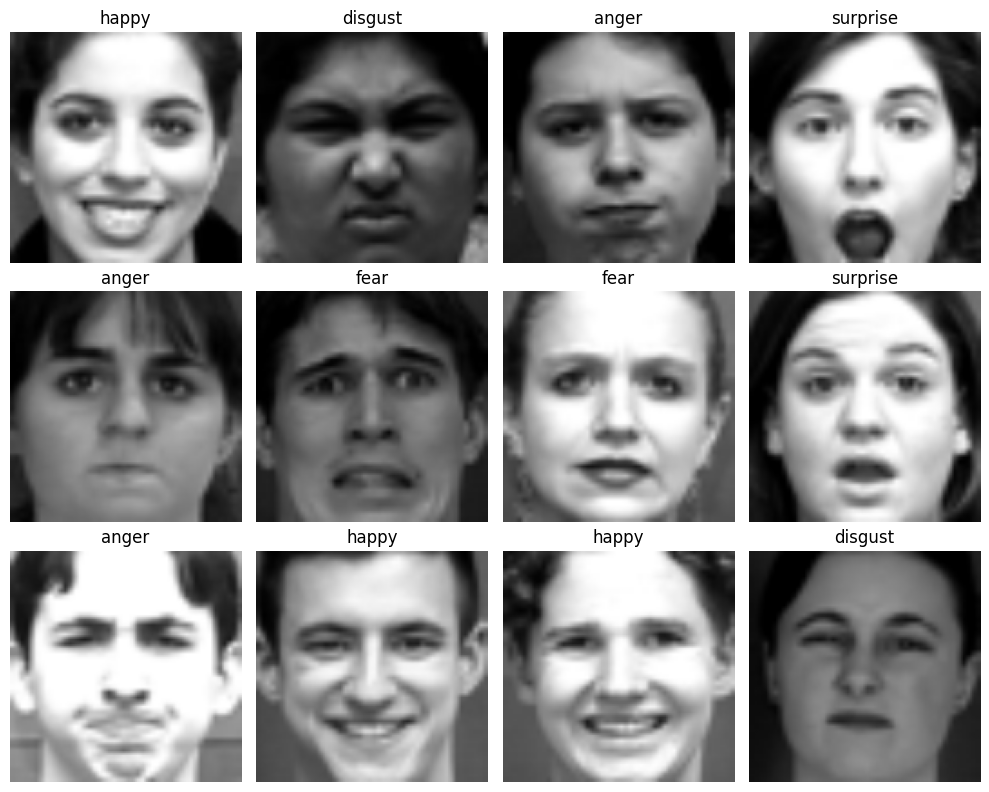

In [61]:
images, labels = next(iter(train_loader))        # load one batch of training images and labels

plt.figure(figsize=(10, 8))                      # create figure for image visualization
for i in range(12):                              # display first 12 images
    plt.subplot(3, 4, i + 1)                     # create grid layout (3 rows x 4 columns)
    img = images[i].permute(1, 2, 0)             # rearrange tensor dimensions for plotting
    plt.imshow(img)                              # display image
    plt.title(class_names[labels[i]])            # display corresponding emotion label
    plt.axis("off")                              # hide axis values and ticks

plt.tight_layout()                               # adjust spacing between images
plt.show()                                       # display final figure

### 6. Build CNN Model

In [62]:
class EmotionCNN(nn.Module):                             # define custom CNN model for emotion classification

    def __init__(self, num_classes):                     # initialize model layers
        super(EmotionCNN, self).__init__()               # inherit functionality from PyTorch neural network module

        self.conv_layers = nn.Sequential(                # convolutional feature extraction layers
            nn.Conv2d(3, 32, kernel_size=3),             # detect low-level image features using 32 filters
            nn.ReLU(),                                   # apply non-linear activation function
            nn.MaxPool2d(2),                             # reduce image dimensions and retain important features

            nn.Conv2d(32, 64, kernel_size=3),            # learn more complex visual patterns using 64 filters
            nn.ReLU(),                                   # introduce non-linearity to improve learning capability
            nn.MaxPool2d(2),                             # reduce feature map size to improve efficiency

            nn.Conv2d(64, 128, kernel_size=3),           # extract deeper and more detailed facial features
            nn.ReLU(),                                   # allow the model to learn complex relationships
            nn.MaxPool2d(2))                             # compress feature maps before classification

        self.fc_layers = nn.Sequential(                  # fully connected classification layers

            nn.Flatten(),                                # convert multidimensional feature maps into a single vector
            nn.Linear(128 * 14 * 14, 128),               # connect extracted features to 128 neurons for learning patterns
            nn.ReLU(),                                   # apply activation function to improve model learning
            nn.Dropout(0.4),                             # randomly disable neurons to reduce overfitting
            nn.Linear(128, num_classes))                 # generate final outputs for each emotion class

    def forward(self, x):                                # define forward propagation process
        x = self.conv_layers(x)                          # extract visual features from input images
        x = self.fc_layers(x)                            # classify extracted features into emotion categories
        return x                                         # return final prediction scores

In [63]:
model = EmotionCNN(num_classes=len(class_names)) # create instance of the CNN model and set output neurons equal to number of emotion classes         
model                                            # display model architecture

EmotionCNN(
  (conv_layers): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc_layers): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=25088, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.4, inplace=False)
    (4): Linear(in_features=128, out_features=7, bias=True)
  )
)

### 7. Loss Function & Optimizer

In [64]:
learning_rate = 0.0001                            # define optimization step size during training

criterion = nn.CrossEntropyLoss()                 # define loss function for multi-class classification
optimizer = optim.Adam(                           # initialize Adam optimizer for Gradient Descent optimization
    model.parameters(),                           # update all trainable model parameters
    lr=learning_rate)                             # apply selected learning rate

### 8. Training with Weight/Bias Tracking

In [65]:
# Training and Validation Loops
def train_one_epoch(model, dataloader, criterion, optimizer):

    model.train()                                      # enable training mode

    total_loss = 0                                     # store total training loss
    correct = 0                                        # count correct predictions
    total = 0                                          # count total training samples

    for images, labels in tqdm(dataloader):            # iterate through training batches with progress bar
        outputs = model(images)                        # generate predictions from input images
        loss = criterion(outputs, labels)              # compute prediction error

        optimizer.zero_grad()                          # clear old gradients before backpropagation
        loss.backward()                                # compute gradients using backpropagation
        optimizer.step()                               # update weights and biases using optimizer

        total_loss += loss.item()                      # accumulate batch loss

        predictions = outputs.argmax(dim=1)              # select predicted class with highest score
        correct += (predictions == labels).sum().item()  # count correct predictions
        total += labels.size(0)                          # count processed images

    avg_loss = total_loss / len(dataloader)            # calculate average training loss
    accuracy = correct / total                         # calculate training accuracy

    return avg_loss, accuracy                          # return training metrics

def validate(model, dataloader, criterion):

    model.eval()                                       # switch model to evaluation mode

    total_loss = 0                                     # store validation loss
    correct = 0                                        # count correct validation predictions
    total = 0                                          # count validation samples

    with torch.no_grad():                              # disable gradient computation during validation
        for images, labels in dataloader:              # iterate through validation batches
            outputs = model(images)                    # generate validation predictions
            loss = criterion(outputs, labels)          # compute validation loss

            total_loss += loss.item()                  # accumulate validation loss

            predictions = outputs.argmax(dim=1)              # select predicted validation class
            correct += (predictions == labels).sum().item()  # count correct predictions
            total += labels.size(0)                          # count validation samples

    avg_loss = total_loss / len(dataloader)            # calculate average validation loss
    accuracy = correct / total                         # calculate validation accuracy

    return avg_loss, accuracy                          # return validation metrics

In [66]:
# Running Training
epochs = 20                                            # define number of training epochs

train_losses = []                                      # store training loss values
val_losses = []                                        # store validation loss values

train_accuracies = []                                  # store training accuracy values
val_accuracies = []                                    # store validation accuracy values


w_values = []                                          # store selected weight values
b_values = []                                          # store selected bias values

for epoch in range(epochs):                            # repeat training process for all epochs

    train_loss, train_accuracy = train_one_epoch(      # train model for one complete epoch
        model,                                         # neural network model
        train_loader,                                  # training dataset batches
        criterion,                                     # loss function
        optimizer)                                     # optimization algorithm

    val_loss, val_accuracy = validate(                 # evaluate model using validation data
        model,                                         # trained neural network model
        val_loader,                                    # validation dataset batches
        criterion)                                     # loss function

    train_losses.append(train_loss)                    # save training loss
    val_losses.append(val_loss)                        # save validation loss

    train_accuracies.append(train_accuracy)            # save training accuracy
    val_accuracies.append(val_accuracy)                # save validation accuracy

    selected_layer = model.fc_layers[-1]               # select final classification layer

    w_values.append(selected_layer.weight[0, 0].item())   # save selected weight value
    b_values.append(selected_layer.bias[0].item())        # save selected bias value
        

 # display epoch results
    print(                                            
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Acc: {val_accuracy:.4f}")

100%|██████████| 25/25 [00:03<00:00,  7.56it/s]


Epoch 1/20 | Train Loss: 1.8662 | Val Loss: 1.7972 | Train Acc: 0.2474 | Val Acc: 0.2538


100%|██████████| 25/25 [00:03<00:00,  7.42it/s]


Epoch 2/20 | Train Loss: 1.8241 | Val Loss: 1.7599 | Train Acc: 0.2793 | Val Acc: 0.2589


100%|██████████| 25/25 [00:03<00:00,  7.51it/s]


...

Epoch 18/20 | Train Loss: 0.2625 | Val Loss: 0.1704 | Train Acc: 0.9145 | Val Acc: 0.9442


100%|██████████| 25/25 [00:03<00:00,  7.76it/s]


Epoch 19/20 | Train Loss: 0.2470 | Val Loss: 0.1731 | Train Acc: 0.9222 | Val Acc: 0.9492


100%|██████████| 25/25 [00:03<00:00,  7.96it/s]


Epoch 20/20 | Train Loss: 0.2542 | Val Loss: 0.1877 | Train Acc: 0.9094 | Val Acc: 0.9239


### 9. Gradient Descent Interpretation

9.1 Loss / Accuracy Curve

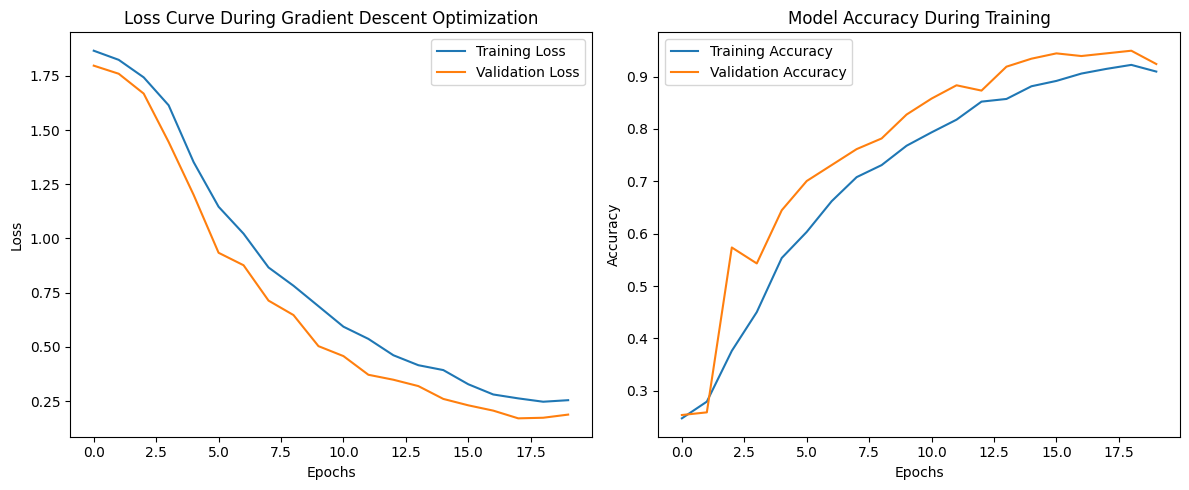

In [67]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)                                                 # create first subplot for loss curves
plt.plot(train_losses, label="Training Loss")                      # plot training loss values across epochs
plt.plot(val_losses, label="Validation Loss")                      # plot validation loss values across epochs
plt.title("Loss Curve During Gradient Descent Optimization")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1,2,2)                                                 # create second subplot for accuracy curves
plt.plot(train_accuracies, label="Training Accuracy")              # plot training accuracy values across epochs
plt.plot(val_accuracies, label="Validation Accuracy")              # plot validation accuracy values across epochs

plt.title("Model Accuracy During Training")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()                                               
plt.show()

9.2 Minimum Loss

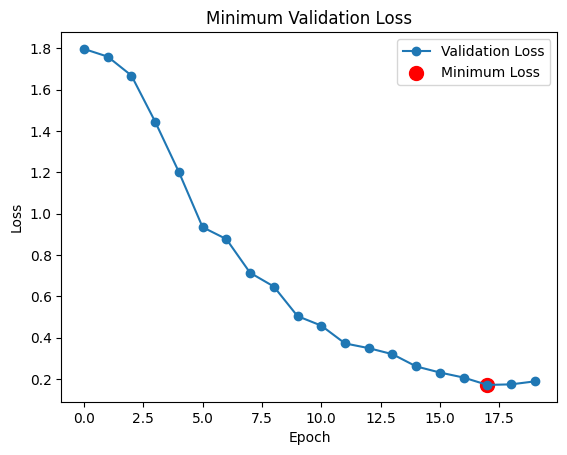

Minimum validation loss: 0.17041635193995067
At epoch: 18


In [68]:
min_epoch = np.argmin(val_losses)                         # find epoch with lowest validation loss
min_loss = val_losses[min_epoch]                          # retrieve minimum loss value

plt.plot(val_losses, marker="o", label="Validation Loss")                   # plot validation loss across epochs
plt.scatter(min_epoch, min_loss, color="red", s=100, label="Minimum Loss")  # highlight minimum loss point on graph

plt.title("Minimum Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

print("Minimum validation loss:", min_loss)
print("At epoch:", min_epoch + 1)

9.3 Validation Loss vs Weight and Bias

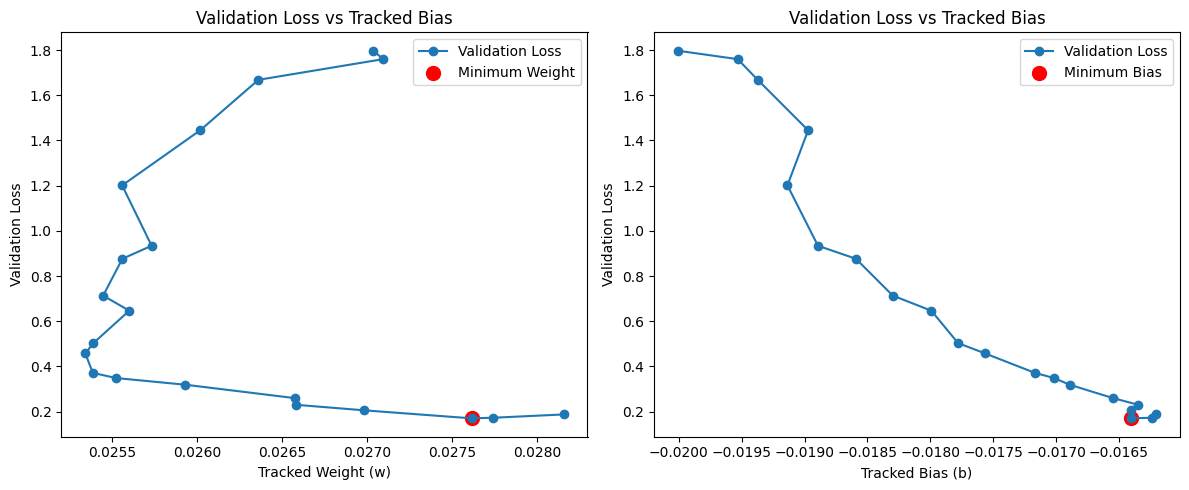

Weight at minimum loss: 0.027613893151283264
Bias at minimum loss: -0.016405237838625908


In [81]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)                                                           # create first subplot for weight analysis
plt.plot(w_values, val_losses, marker="o", label="Validation Loss")                                   # plot validation loss against selected weight values
plt.scatter(w_values[min_epoch], val_losses[min_epoch], color="red", s=100, label="Minimum Weight")   # highlight minimum loss point on the graph

plt.title("Validation Loss vs Tracked Bias")
plt.xlabel("Tracked Weight (w)")
plt.ylabel("Validation Loss")
plt.legend()

plt.subplot(1,2,2)                                                           # create second subplot for bias analysis
plt.plot(b_values, val_losses, marker="o", label="Validation Loss")                                   # plot validation loss against tracked bias values
plt.scatter(b_values[min_epoch], val_losses[min_epoch], color="red", s=100, label="Minimum Bias")     # highlight minimum loss point on graph

plt.title("Validation Loss vs Tracked Bias")
plt.xlabel("Tracked Bias (b)")
plt.ylabel("Validation Loss")
plt.legend()

plt.tight_layout()  
plt.show()

print("Weight at minimum loss:", w_values[min_epoch])   # display weight value at minimum loss point
print("Bias at minimum loss:", b_values[min_epoch])     # display bias value at minimum loss point

### 10. Evaluation

In [70]:
model.eval()                                          # switch model to evaluation mode

all_labels = []                                       # store true emotion labels
all_predictions = []                                  # store predicted emotion labels

with torch.no_grad():                                 # disable gradient computation during evaluation
    for images, labels in val_loader:                 # iterate through validation batches
        outputs = model(images)                       # generate predictions from validation images
        _, predicted = torch.max(outputs, 1)          # select class with highest prediction score

        all_labels.extend(labels.numpy())             # save true labels into list
        all_predictions.extend(predicted.numpy())     # save predicted labels into list

In [71]:
 # display detailed classification performance metrics
print(classification_report(                        
    all_labels,                                      # true emotion labels
    all_predictions,                                 # predicted emotion labels
    target_names=class_names))                       # display emotion class names in the report

              precision    recall  f1-score   support

       anger       0.71      0.96      0.81        23
    contempt       1.00      0.73      0.84        11
     disgust       1.00      0.86      0.93        37
        fear       1.00      0.94      0.97        16
       happy       0.98      1.00      0.99        42
     sadness       0.93      0.72      0.81        18
    surprise       0.93      1.00      0.96        50

    accuracy                           0.92       197
   macro avg       0.93      0.89      0.90       197
weighted avg       0.94      0.92      0.92       197



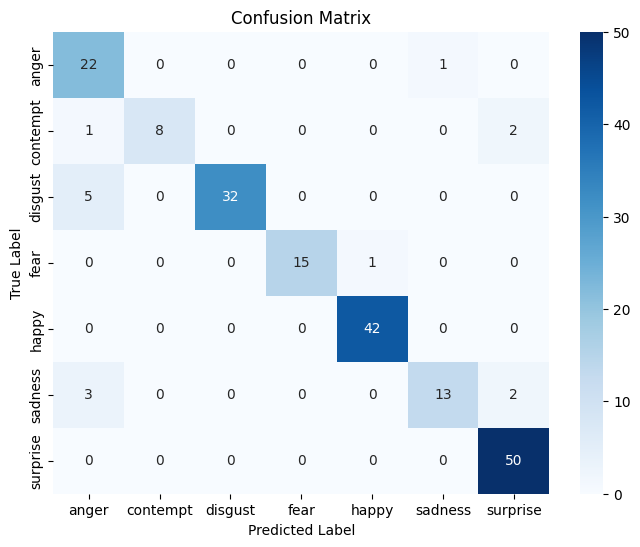

In [72]:
cm = confusion_matrix(all_labels, all_predictions)   # compute confusion matrix using true and predicted labels

plt.figure(figsize=(8, 6))                          
sns.heatmap(                                         # display confusion matrix as heatmap
    cm,                                              
    annot=True,                                      
    fmt="d",                                         # display values as integers
    cmap="Blues",                                   
    xticklabels=class_names,                         # display predicted emotion labels
    yticklabels=class_names)                         # display true emotion labels

plt.title("Confusion Matrix")                       
plt.xlabel("Predicted Label")                        
plt.ylabel("True Label")                             
plt.show()                                           

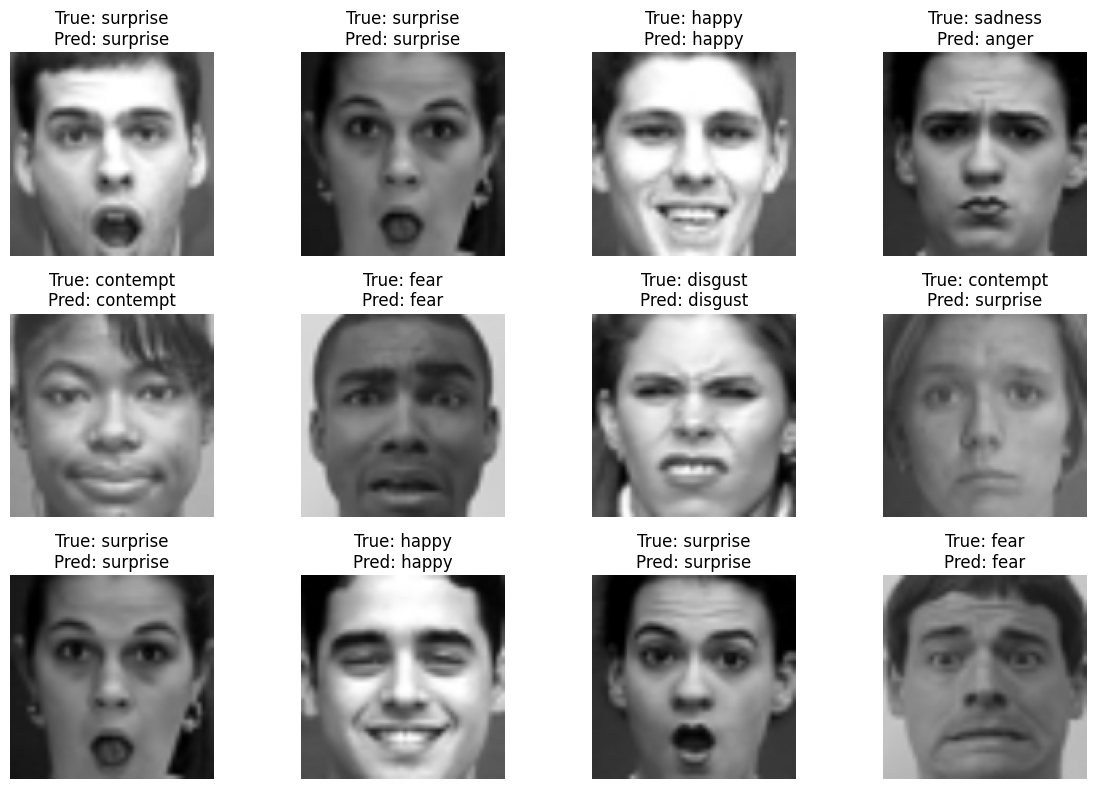

In [ ]:
images, labels = next(iter(val_loader))                 # load one batch from validation dataset
model.eval()                                            # switch model to evaluation mode

with torch.no_grad():                                   # disable gradient computation during testing
    outputs = model(images)                             # generate predictions for validation images
    _, predictions = torch.max(outputs, 1)              # select class with highest prediction score

plt.figure(figsize=(12,8))                              # create figure for visualization
for i in range(12):                                     # display first 12 images
    plt.subplot(3,4,i+1)                                # create grid layout (3 rows × 4 columns)  
                          
    img = images[i].permute(1,2,0)                      # rearrange image dimensions for plotting
                       
    plt.imshow(img)                                     # display image

    true_label = class_names[labels[i]]                 # retrieve true emotion label
    pred_label = class_names[predictions[i]]            # retrieve predicted emotion label

    plt.title(f"True: {true_label}\nPred: {pred_label}") # display true and predicted labels
    plt.axis("off")                                     


plt.tight_layout()                                     
plt.show()                                             

In [82]:
# calculate average prediction accuracy
final_accuracy = np.mean(np.array(all_predictions) == np.array(all_labels)) # compare predicted labels with true labels                       
print("Final Validation Accuracy:", final_accuracy)  # display final validation accuracy

Final Validation Accuracy: 0.9238578680203046


In [ ]:
#np.save("w_values.npy", np.array(w_values))
#np.save("b_values.npy", np.array(b_values))
#np.save("val_losses.npy", np.array(val_losses))

### Since we successfully optimized and trained the emotion detection model, we can now finally measure students’ emotional damage during math lectures in real time 🤣
